# Week 3 — Day 1: XAI fundamentals + curate examples

Tasks:
- Conceptual: XAI fundamentals -- local vs. global explanations, attribution methods, why
  explainability matters for multimodal models
- Select 10-15 representative images from Week 2 results (mix of good and poor captions) for use
  throughout the week

Deliverable: curated example set (image + generated caption + ground truth caption) saved to
`data/xai_examples/`.

## XAI concepts (brief)

- **Local vs. global explanations**: local explains one prediction (why did the model caption
  *this* image *this* way); global describes overall model behavior across many inputs. This week
  is entirely local -- explaining individual captions.
- **Attribution methods**: assign an importance score to each input feature (image
  pixels/regions, input tokens) for a given output. **Grad-CAM** (Day 2) attributes importance to
  spatial regions of the image via gradients flowing back through the vision encoder's
  convolutional/attention feature maps. **SHAP/LIME** (Day 3) perturb inputs and observe output
  change to attribute importance to text tokens (or image regions) in a model-agnostic way.
- **Why it matters for multimodal models**: a caption can be "correct" for the wrong reason (e.g.
  right word, attending to background instead of the actual subject) -- attribution reveals *what
  the model actually looked at*, which raw accuracy metrics (BLEU/ROUGE, Week 2) cannot show.

Our winning Week 2 model (`config C`: BLIP fine-tuned at lr=5e-5, vision encoder frozen, beam-search
decoding) is what we explain for the rest of this week.

### 1. Load the winning fine-tuned model

In [1]:
import os
import random
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
from rouge_score import rouge_scorer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

from transformers import BlipProcessor, BlipForConditionalGeneration

CHECKPOINT_DIR = "../results/config_A_checkpoint"   # config C's weights == config A's weights
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(CHECKPOINT_DIR).to(device)
model.eval()
print("Fine-tuned model loaded.")

Using device: cpu


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


[transformers] The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Fine-tuned model loaded.


### 2. Generate captions (beam search) on a sample and score each one

In [2]:
captions_path = '../data/captions.txt'
img_dir = '../data/Images'

df = pd.read_csv(captions_path)
df.columns = ['image', 'caption']

random.seed(11)
all_images = df['image'].drop_duplicates().tolist()
sample_images = random.sample(all_images, 150)

# Always include the puppy image BLIP zero-shot miscaptioned as "a small pig" in Week 2 Day 1 --
# a natural case study for Grad-CAM.
KNOWN_MISCAPTION_IMAGE = '2741051940_89fb6b2cee.jpg'
if KNOWN_MISCAPTION_IMAGE not in sample_images:
    sample_images.append(KNOWN_MISCAPTION_IMAGE)

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

@torch.no_grad()
def generate_caption(img_path):
    image = Image.open(img_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30, num_beams=4)
    return processor.decode(out[0], skip_special_tokens=True)

records = []
for img_name in tqdm(sample_images):
    pred = generate_caption(os.path.join(img_dir, img_name))
    refs = df[df['image'] == img_name]['caption'].tolist()
    best_score = max(scorer.score(ref, pred)['rougeL'].fmeasure for ref in refs)
    records.append({"image": img_name, "predicted_caption": pred, "best_ground_truth": max(
        refs, key=lambda ref: scorer.score(ref, pred)['rougeL'].fmeasure
    ), "rougeL": best_score})

scored_df = pd.DataFrame(records).sort_values('rougeL', ascending=False).reset_index(drop=True)
scored_df.head()

  0%|          | 0/151 [00:00<?, ?it/s]

  1%|          | 1/151 [00:10<25:38, 10.26s/it]

  1%|▏         | 2/151 [00:17<20:21,  8.20s/it]

  2%|▏         | 3/151 [00:23<18:46,  7.61s/it]

  3%|▎         | 4/151 [00:29<16:39,  6.80s/it]

...

 99%|█████████▊| 149/151 [15:05<00:11,  5.50s/it]

 99%|█████████▉| 150/151 [15:10<00:05,  5.32s/it]

100%|██████████| 151/151 [15:15<00:00,  5.44s/it]

100%|██████████| 151/151 [15:15<00:00,  6.07s/it]

,image,predicted_caption,best_ground_truth,rougeL
0,1526181215_c1a94325ae.jpg,a brown dog jumping into the water.,a dog jumps into the water .,0.923077
1,2541104331_a2d65cfa54.jpg,a brown dog splashes through the water.,A brown dog splashing through water .,0.923077
2,2741051940_89fb6b2cee.jpg,a black and white dog is playing with a plasti...,A white dog is playing with a plastic bag .,0.900000
3,3154813159_58a195236d.jpg,a brown and white dog is standing on its hind ...,The brown and white dog is standing up on its ...,0.869565
4,2708686056_1b8f356264.jpg,a girl in a blue swimsuit is running into the ...,A girl in a blue swimsuit walks into the ocean .,0.857143


### 3. Pick 15 examples: mix of good and poor captions

In [3]:
GOOD_N = 7
POOR_N = 7

good_examples = scored_df.head(GOOD_N).copy()
good_examples['bucket'] = 'good'

remaining = scored_df.iloc[GOOD_N:].sort_values('rougeL')
poor_examples = remaining.head(POOR_N).copy()
poor_examples['bucket'] = 'poor'

curated_df = pd.concat([good_examples, poor_examples]).reset_index(drop=True)

# Make sure the known Week 2 miscaption case is in the set, labeled by where it actually falls
if KNOWN_MISCAPTION_IMAGE not in curated_df['image'].values:
    known_row = scored_df[scored_df['image'] == KNOWN_MISCAPTION_IMAGE].copy()
    median_score = scored_df['rougeL'].median()
    known_row['bucket'] = 'poor' if known_row['rougeL'].iloc[0] <= median_score else 'good'
    curated_df = pd.concat([curated_df, known_row]).reset_index(drop=True)

print(f"Curated {len(curated_df)} examples: {(curated_df['bucket']=='good').sum()} good, {(curated_df['bucket']=='poor').sum()} poor")
curated_df

Curated 14 examples: 7 good, 7 poor


,image,predicted_caption,best_ground_truth,rougeL,bucket
0,1526181215_c1a94325ae.jpg,a brown dog jumping into the water.,a dog jumps into the water .,0.923077,good
1,2541104331_a2d65cfa54.jpg,a brown dog splashes through the water.,A brown dog splashing through water .,0.923077,good
2,2741051940_89fb6b2cee.jpg,a black and white dog is playing with a plasti...,A white dog is playing with a plastic bag .,0.900000,good
3,3154813159_58a195236d.jpg,a brown and white dog is standing on its hind ...,The brown and white dog is standing up on its ...,0.869565,good
4,2708686056_1b8f356264.jpg,a girl in a blue swimsuit is running into the ...,A girl in a blue swimsuit walks into the ocean .,0.857143,good
5,2326730558_75c20e5033.jpg,two brown dogs are playing in the snow.,Two dogs play in the snow .,0.857143,good
6,3091912922_0d6ebc8f6a.jpg,a brown dog is running with a yellow ball in i...,A dog runs with a yellow toy in its mouth .,0.818182,good
7,2332986053_864db84971.jpg,a bearded bearded bearded bearded bearded bear...,A man wearing a helmet and sunglasses smiles .,0.055556,poor
8,3561543598_3c1b572f9b.jpg,a man in a white shirt and a man in a black an...,A group of men wearing uniforms with hats gath...,0.222222,poor
9,3280672302_2967177653.jpg,a man and a woman are posing for the camera.,a boy carries a teenager on his back .,0.222222,poor


### 4. Save the curated set: metadata + copied images

In [4]:
import shutil

xai_dir = '../data/xai_examples'
xai_img_dir = os.path.join(xai_dir, 'images')
os.makedirs(xai_img_dir, exist_ok=True)

for img_name in curated_df['image']:
    shutil.copy(os.path.join(img_dir, img_name), os.path.join(xai_img_dir, img_name))

curated_df.to_csv(os.path.join(xai_dir, 'curated_examples.csv'), index=False)
print(f"Saved {len(curated_df)} curated examples to {xai_dir}/")

Saved 14 curated examples to ../data/xai_examples/


### 5. Visual check: the curated set

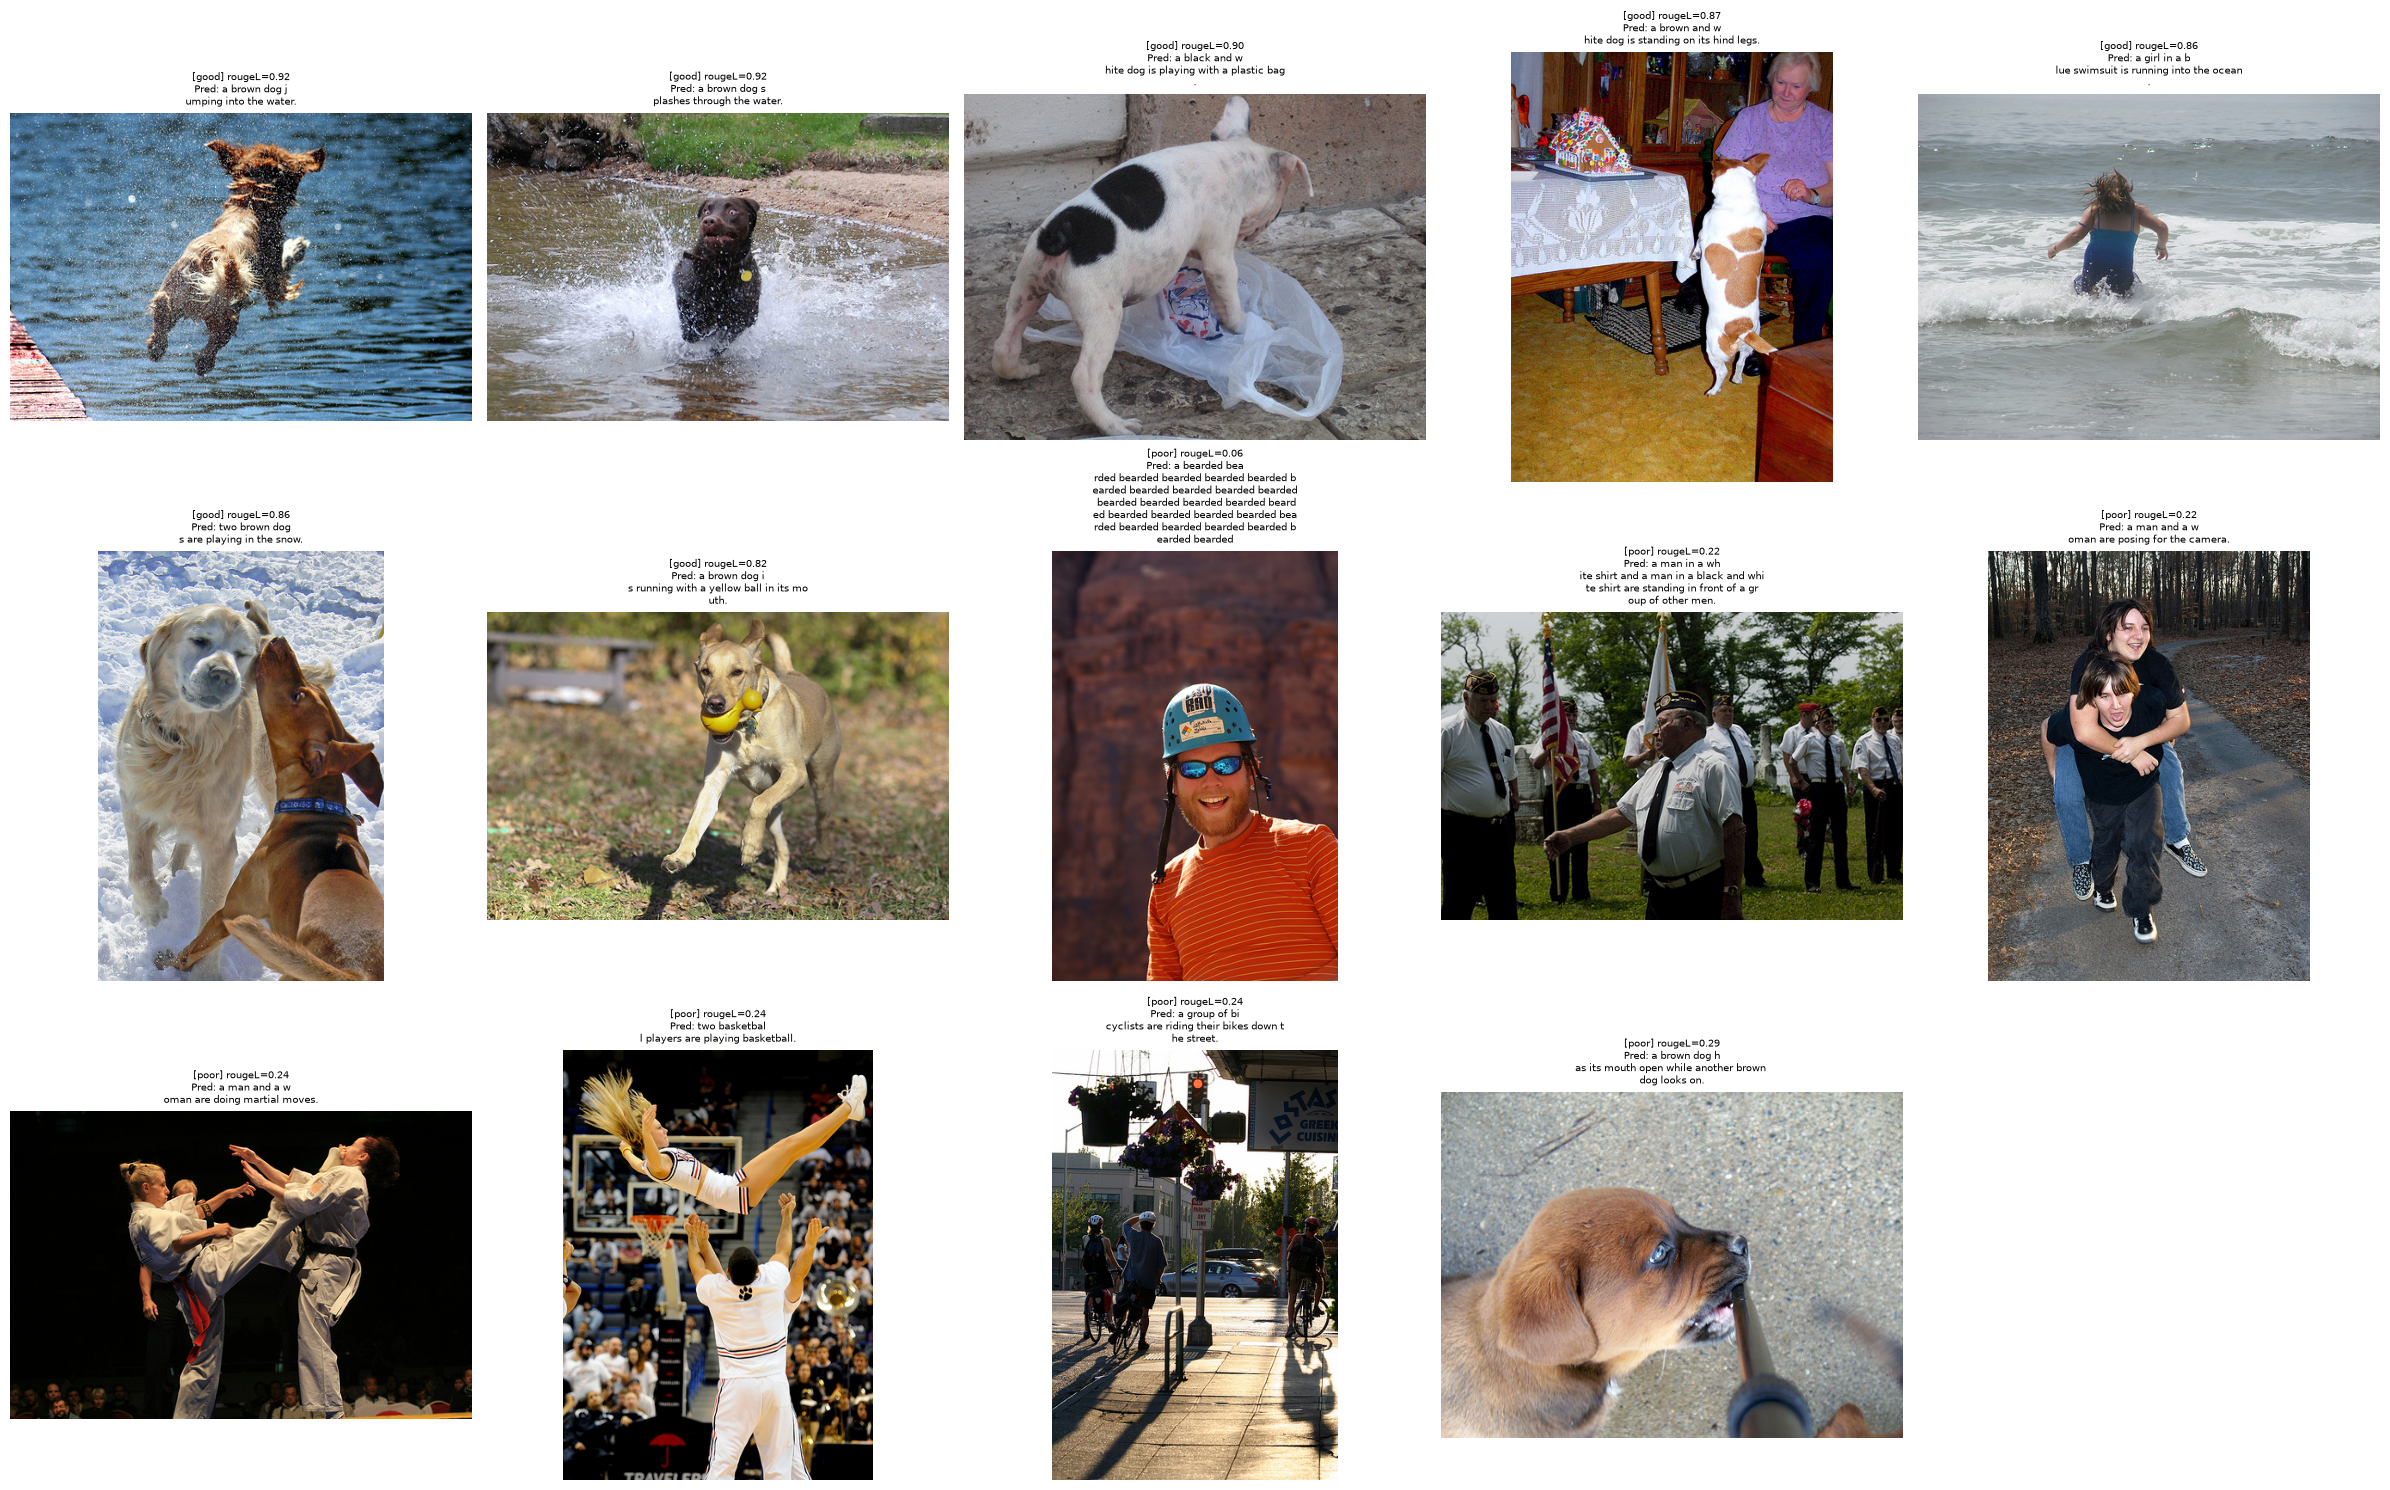

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(24, 15))
for ax, (_, row) in zip(axes.flat, curated_df.iterrows()):
    img = Image.open(os.path.join(img_dir, row['image'])).convert('RGB')
    ax.imshow(img)
    title = f"[{row['bucket']}] rougeL={row['rougeL']:.2f}\nPred: {row['predicted_caption']}"
    wrapped = '\n'.join([title[i:i+38] for i in range(0, len(title), 38)])
    ax.set_title(wrapped, fontsize=7)
    ax.axis('off')
for ax in axes.flat[len(curated_df):]:
    ax.axis('off')
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/week3_curated_examples_grid.png', dpi=120)
plt.show()